In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

import model_utils
from pathlib import Path
from model_utils import get_multiple_choice_fields, get_binary_classification_fields, get_classification_fields, get_regression_fields
from constants import AnnotationsReduced

from pprint import pprint

# Not reduced datset

In [2]:
plt.style.use('ggplot')

# Parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"
TEST_FILE_NAME = "test_split.csv"

In [3]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 175
len(validation_data) = 43
len(test_data) = 57


In [4]:
mc_fields = get_multiple_choice_fields(AnnotationsReduced)
cl_fields = get_classification_fields(AnnotationsReduced)
bc_fields = get_binary_classification_fields(AnnotationsReduced)
for field in train_data.columns:
    if field not in mc_fields + cl_fields + bc_fields:
        print(f"Field '{field}' not in any known annotation fields.")

Field 'report_text' not in any known annotation fields.
Field 'profile' not in any known annotation fields.
Field 'ore_inizio' not in any known annotation fields.
Field 'ore_fine' not in any known annotation fields.
Field 'spessore_parietale' not in any known annotation fields.
Field 'estensione_cranio_caudale' not in any known annotation fields.
Field 'distanza_oai' not in any known annotation fields.
Field 'numero_linfonodi_non_conosciuto' not in any known annotation fields.
Field 'linfonodi_sospetti' not in any known annotation fields.
Field 'numero_depositi' not in any known annotation fields.
Field 'split' not in any known annotation fields.


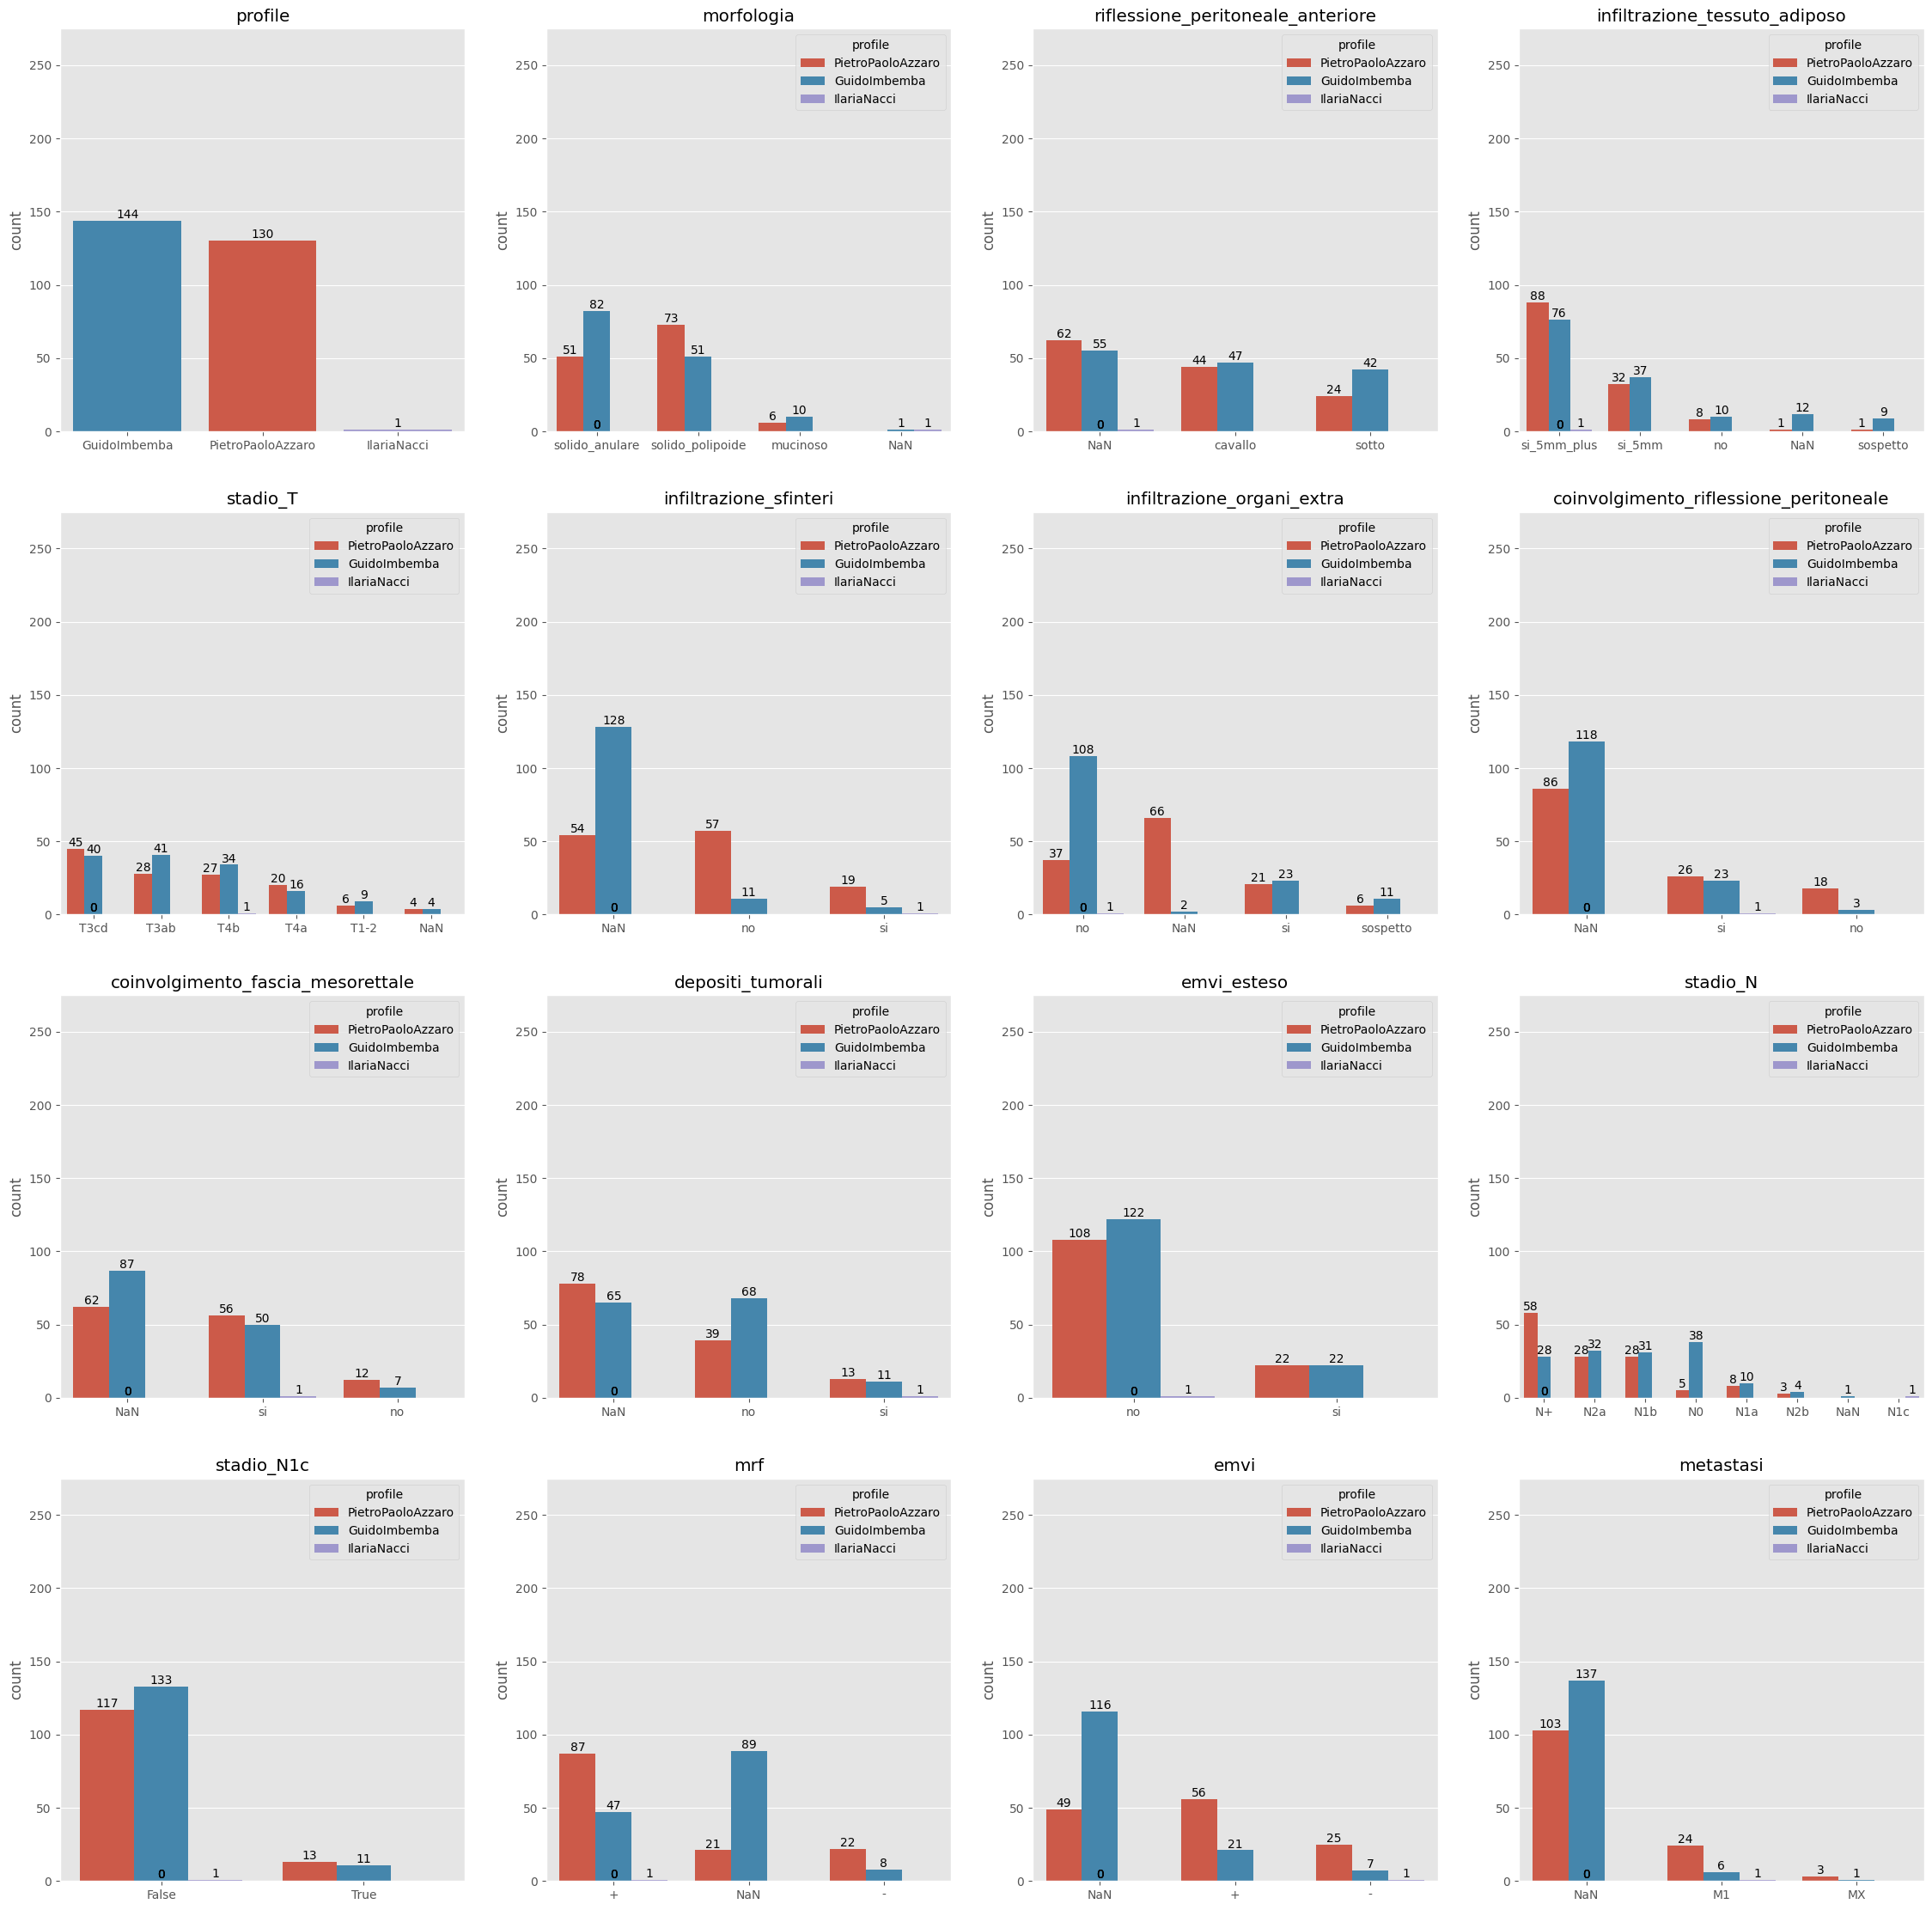

In [5]:
fields = ['profile'] + cl_fields + bc_fields
n_cols = 4
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 7*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'),
                  ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='profile')
                  #ax=ax, order=total_data.fillna('NaN')[field].value_counts().index)
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()

Si osserva che la quantità di referti annotati dai due annotatori (Guido e Pietropaolo) è simile, con un numero leggermente meggiore per Guido. Per questo, ci aspettiamo che anche per gli altri campi la distribuzione sia simile. Questo non accade per i seguenti campi:
- morfologia (solido anulare e solido polipoide)
- infiltrazione sfinteri
- infiltrazione organi extra
- coinvolgimento riflessione peritoneale
- coinvolgimento fascia mesorettale
- stadio N (N+ e N0)
- mrf
- emvi
- metastasi

Analizziamo ora solo i report annotati da Guido

modifiche da apportare:
- aggreghiamo MX a NaN per ottenere quindi solo due classi: M1 e NaN
- potremmo aggregare T4a con T4b
- si potrebbe aggregare lo stadio N in N+ e N0
- per MRF si potrebbe aggregare "-" con NaN
- aggreghiamo mucinoso con NaN e lo facciamo diventare altro
- in infiltrazione organi extra aggreghiamo no con NaN e si con sospetto
- coinvolgimento fascia mesorettale, aggreghiamo no con NaN
- coinvolgimento riflessione peritoneale: aggreghiamo no con nan
- per i depositi tumorali aggreghiamo no con NaN
- aggreghiamo no e NaN anche per infiltrazione sfinteri
- aggreghiamo - e NaN anche per mrf
- aggreghiamo - e NaN anche per emvi

# Reduced dataset

In [6]:
plt.style.use('ggplot')

# Parameters
TRAIN_FILE_NAME = "train_split_reduced.csv"
VALIDATION_FILE_NAME = "validation_split_reduced.csv"
TEST_FILE_NAME = "test_split_reduced.csv"

In [7]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 166
len(validation_data) = 54
len(test_data) = 55


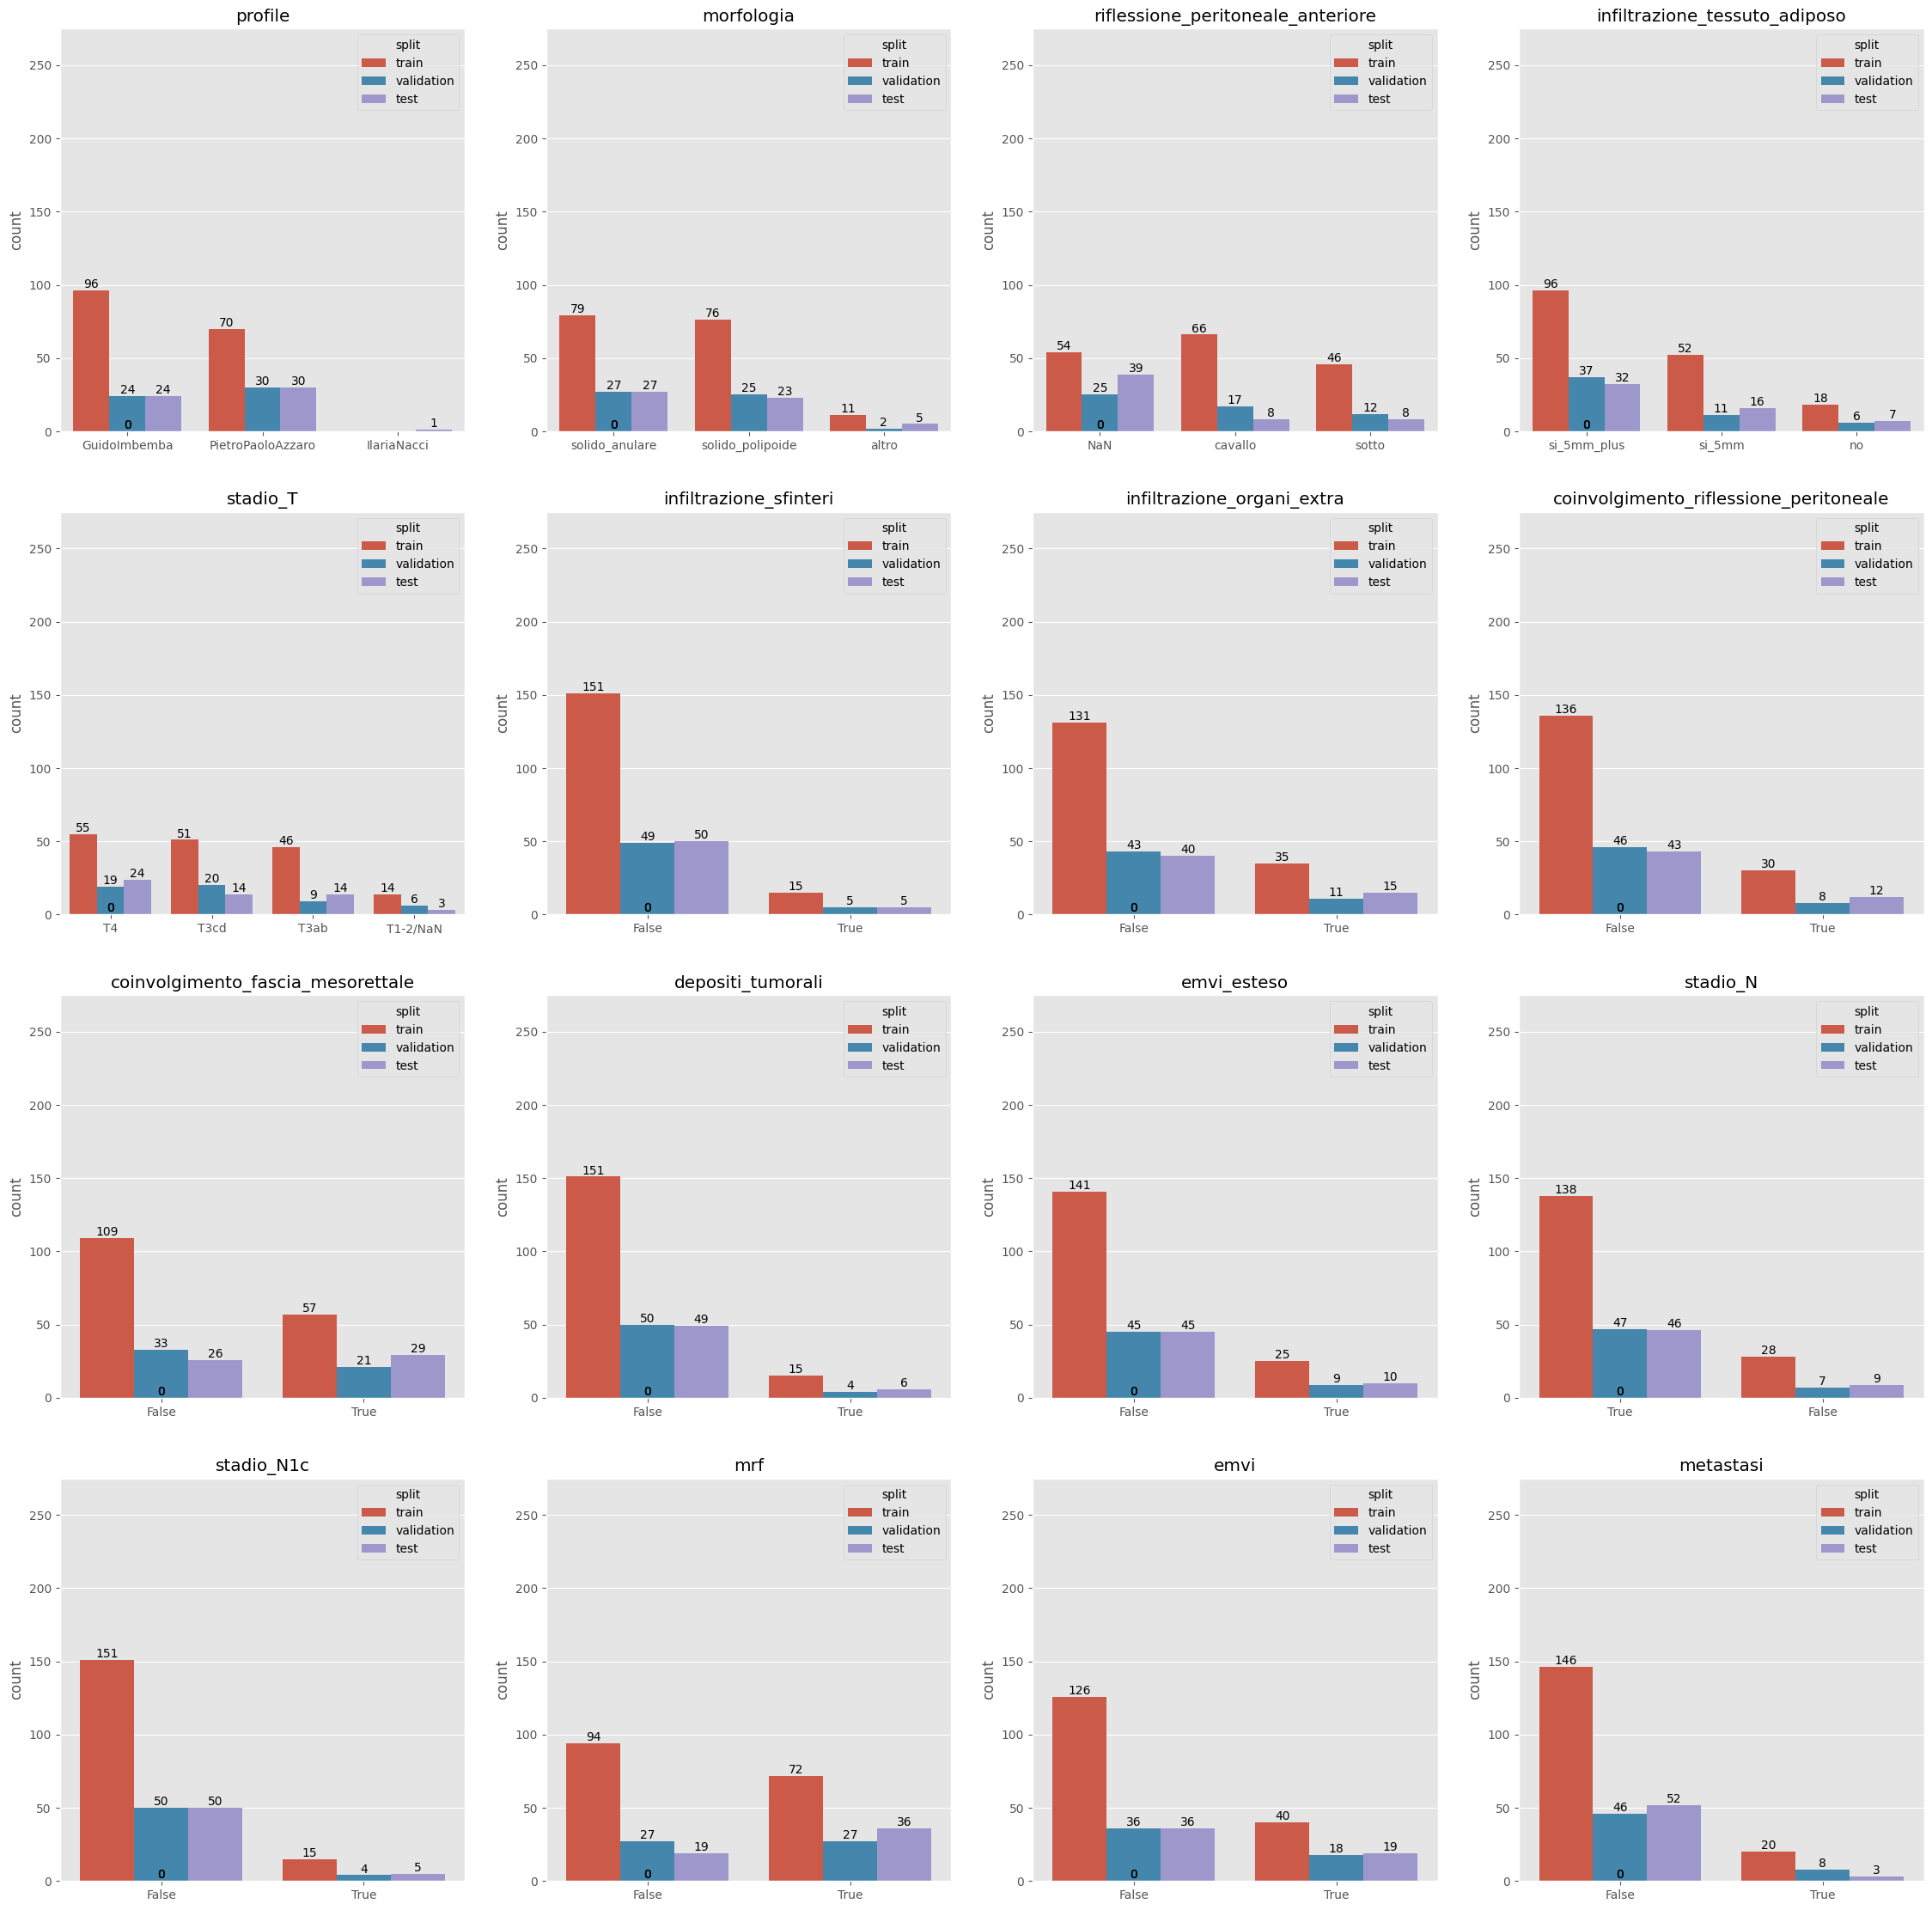

In [8]:
fields = ['profile'] + cl_fields + bc_fields
n_cols = 4
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 7*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'),
                  ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='split')
                  #ax=ax, order=total_data.fillna('NaN')[field].value_counts().index)
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()

# Prove modello

In [9]:
get_binary_classification_fields(AnnotationsReduced)

['infiltrazione_sfinteri',
 'infiltrazione_organi_extra',
 'coinvolgimento_riflessione_peritoneale',
 'coinvolgimento_fascia_mesorettale',
 'depositi_tumorali',
 'emvi_esteso',
 'stadio_N',
 'stadio_N1c',
 'mrf',
 'emvi',
 'metastasi']

In [10]:
get_classification_fields(AnnotationsReduced)

['morfologia',
 'riflessione_peritoneale_anteriore',
 'infiltrazione_tessuto_adiposo',
 'stadio_T']

In [11]:
get_multiple_choice_fields(AnnotationsReduced)

['posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi']

In [12]:
get_regression_fields(AnnotationsReduced)

[]

In [13]:
model_utils.get_field_values(AnnotationsReduced)

{'morfologia': ['solido_polipoide', 'solido_anulare', 'altro'],
 'posizione': ['basso', 'medio', 'alto', 'giunzione'],
 'riflessione_peritoneale_anteriore': ['sotto', 'cavallo', 'NaN'],
 'infiltrazione_tessuto_adiposo': ['no', 'si_5mm', 'si_5mm_plus'],
 'infiltrazione_sfinteri': [False, True],
 'infiltrazione_organi_extra': [False, True],
 'infiltrazione_organi_dettagli': ['pavimento_pelvico', 'altro'],
 'coinvolgimento_riflessione_peritoneale': [False, True],
 'coinvolgimento_fascia_mesorettale': [False, True],
 'sedi_linfonodi': ['mesorettali',
  'rettali_superiori',
  'otturatori',
  'iliaci',
  'altro'],
 'depositi_tumorali': [False, True],
 'emvi_esteso': [False, True],
 'stadio_T': ['T1-2/NaN', 'T3ab', 'T3cd', 'T4'],
 'stadio_N': [False, True],
 'stadio_N1c': [False, True],
 'mrf': [False, True],
 'emvi': [False, True],
 'metastasi': [False, True]}

In [14]:
model_utils.get_number_of_classes(AnnotationsReduced)

{'morfologia': 3,
 'posizione': 4,
 'riflessione_peritoneale_anteriore': 3,
 'infiltrazione_tessuto_adiposo': 3,
 'infiltrazione_sfinteri': 2,
 'infiltrazione_organi_extra': 2,
 'infiltrazione_organi_dettagli': 2,
 'coinvolgimento_riflessione_peritoneale': 2,
 'coinvolgimento_fascia_mesorettale': 2,
 'sedi_linfonodi': 5,
 'depositi_tumorali': 2,
 'emvi_esteso': 2,
 'stadio_T': 4,
 'stadio_N': 2,
 'stadio_N1c': 2,
 'mrf': 2,
 'emvi': 2,
 'metastasi': 2}

In [15]:
pprint(model_utils.create_label_to_id_map(AnnotationsReduced))

{'coinvolgimento_fascia_mesorettale': {'id_to_label': {0: False, 1: True},
                                       'label_to_id': {False: 0, True: 1}},
 'coinvolgimento_riflessione_peritoneale': {'id_to_label': {0: False, 1: True},
                                            'label_to_id': {False: 0, True: 1}},
 'depositi_tumorali': {'id_to_label': {0: False, 1: True},
                       'label_to_id': {False: 0, True: 1}},
 'emvi': {'id_to_label': {0: False, 1: True},
          'label_to_id': {False: 0, True: 1}},
 'emvi_esteso': {'id_to_label': {0: False, 1: True},
                 'label_to_id': {False: 0, True: 1}},
 'infiltrazione_organi_dettagli': {'id_to_label': {0: 'pavimento_pelvico',
                                                   1: 'altro'},
                                   'label_to_id': {'altro': 1,
                                                   'pavimento_pelvico': 0}},
 'infiltrazione_organi_extra': {'id_to_label': {0: False, 1: True},
                      

In [16]:
model_utils.labels_to_bits(['basso', 'giunzione'], model_utils.create_label_to_id_map(AnnotationsReduced)['posizione']['label_to_id'])

[1, 0, 0, 1]

In [17]:
model_utils.bits_to_labels([0, 1, 1, 0], model_utils.create_label_to_id_map(AnnotationsReduced)['posizione']['id_to_label'])

['medio', 'alto']